In [1]:
!pip install -q tensorflow==2.0.0-beta1

tensorflow-serving-api 1.14.0 has requirement tensorflow~=1.14.0, but you'll have tensorflow 2.0.0b1 which is incompatible.
You are using pip version 10.0.1, however version 19.3.1 is available.
You should consider upgrading via the 'pip install --upgrade pip' command.


In [2]:
!pip install -q statsmodels==0.9.0

tensorflow-serving-api 1.14.0 has requirement tensorflow~=1.14.0, but you'll have tensorflow 2.0.0b1 which is incompatible.
You are using pip version 10.0.1, however version 19.3.1 is available.
You should consider upgrading via the 'pip install --upgrade pip' command.


In [3]:
!pip install -q scipy==1.2

tensorflow-serving-api 1.14.0 has requirement tensorflow~=1.14.0, but you'll have tensorflow 2.0.0b1 which is incompatible.
You are using pip version 10.0.1, however version 19.3.1 is available.
You should consider upgrading via the 'pip install --upgrade pip' command.


In [4]:
import os
import csv
import random
import statsmodels.api as sm
import statsmodels.formula.api as smf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.preprocessing import MinMaxScaler

dtypes = {
        'IsCanceled':                                    'float64',
        'LeadTime':                                          'float64',
        'StaysInWeekendNights':                                     'float64',
        'StaysInWeekNights':                                     'float64',
        'Adults':                            'float64',
        'Children':                            'float64',
        'Babies':                                  'float64',
        'Meal':                                    'category',
        'Country':                                               'category',
        'MarketSegment':                                    'category',
        'DistributionChannel':                                       'category',
        'IsRepeatedGuest':                               'float64',
        'PreviousCancellations':                                    'float64',
        'PreviousBookingsNotCanceled':                          'float64',
        'ReservedRoomType':                                             'category',
        'AssignedRoomType':                                            'category',
        'BookingChanges':                                                'float64',
        'DepositType':                                              'category',
        'Agent':                                              'category',
        'Company':                                 'category',
        'DaysInWaitingList':                                           'float64',
        'CustomerType':                                           'category',
        'ADR':                                          'float64',
        'RequiredCarParkingSpaces':                                      'float64',
        'TotalOfSpecialRequests':                                              'float64',
        'ReservationStatus':                                                'category'
        }

In [5]:
train_df = pd.read_csv('H1.csv', dtype=dtypes, converters={'ArrivalDateWeekNumber': '{:0>2}'.format})
a=train_df.head()
b=train_df
b
c=b.sort_values(['ArrivalDateYear','ArrivalDateWeekNumber'], ascending=True)
c=pd.DataFrame(c)
c
type(c)

pandas.core.frame.DataFrame

In [6]:
from pandas import DataFrame  

df = DataFrame(c, columns= ['ArrivalDateYear', 'ArrivalDateWeekNumber']) 
df

,ArrivalDateYear,ArrivalDateWeekNumber
73,2015,27
272,2015,27
303,2015,27
339,2015,27
430,2015,27
529,2015,27
756,2015,27
874,2015,27
1182,2015,27
1279,2015,27


In [7]:
# https://datatofish.com/concatenate-values-python/

df1 = df['ArrivalDateYear'].map(str) + df['ArrivalDateWeekNumber'].map(str)
print (df1)
df1=pd.DataFrame(df1)

73       201527
272      201527
303      201527
339      201527
430      201527
529      201527
756      201527
874      201527
1182     201527
1279     201527
1701     201527
2605     201527
2741     201527
2841     201527
2899     201527
2963     201527
3114     201527
3284     201527
3298     201527
3753     201527
3771     201527
3978     201527
3997     201527
4004     201527
4223     201527
4272     201527
5000     201527
5651     201527
5689     201527
7061     201527
          ...  
16435    201735
16517    201735
16521    201735
16734    201735
16861    201735
17272    201735
17276    201735
17294    201735
17382    201735
17384    201735
17786    201735
17930    201735
18390    201735
18446    201735
18659    201735
18743    201735
18807    201735
18815    201735
18824    201735
18838    201735
18849    201735
18897    201735
19168    201735
19318    201735
19320    201735
19419    201735
19471    201735
19532    201735
19666    201735
19725    201735
Length: 20000, dtype: ob

In [8]:
df2 = DataFrame(c, columns= ['IsCanceled']) 
df2

,IsCanceled
73,1.0
272,0.0
303,0.0
339,0.0
430,0.0
529,0.0
756,0.0
874,0.0
1182,0.0
1279,1.0


In [9]:
type(df1)

pandas.core.frame.DataFrame

In [10]:
df3=pd.concat([df1, df2], axis = 1).T.drop_duplicates().T
df3
df3.columns = ['FullDate', 'IsCanceled']

In [11]:
df3
df3.sort_values(['FullDate','IsCanceled'], ascending=True)

,FullDate,IsCanceled
272,201527,0
303,201527,0
339,201527,0
430,201527,0
529,201527,0
756,201527,0
874,201527,0
1182,201527,0
2605,201527,0
2741,201527,0


In [12]:
df4 = df3.groupby('FullDate').agg(sum)
df4
df4.sort_values(['FullDate'], ascending=True)

,IsCanceled
FullDate,
201527,40.0
201528,45.0
201529,79.0
201530,69.0
201531,95.0
201532,62.0
201533,87.0
201534,61.0
201535,78.0


In [13]:
tseries=df4['IsCanceled']
tseries

FullDate
201527     40.0
201528     45.0
201529     79.0
201530     69.0
201531     95.0
201532     62.0
201533     87.0
201534     61.0
201535     78.0
201536    139.0
201537     71.0
201538    175.0
201539    109.0
201540     83.0
201541    175.0
201542     16.0
201543     81.0
201544     40.0
201545     39.0
201546     45.0
201547     62.0
201548     14.0
201549    114.0
201550     20.0
201551     33.0
201552     70.0
201553     39.0
201601     33.0
201602     37.0
201603     12.0
          ...  
201706     82.0
201707     92.0
201708    115.0
201709     70.0
201710    117.0
201711     74.0
201712     45.0
201713     94.0
201714     91.0
201715    153.0
201716     88.0
201717     96.0
201718    152.0
201719     90.0
201720     73.0
201721    109.0
201722    181.0
201723    108.0
201724    132.0
201725    118.0
201726    147.0
201727    121.0
201728    122.0
201729    137.0
201730    144.0
201731    155.0
201732    127.0
201733    166.0
201734    128.0
201735     91.0
Name: IsCancele

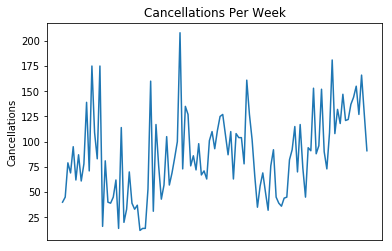

In [14]:
import matplotlib.pyplot as plt
plt.plot(tseries)
plt.tick_params(
    axis='x',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    bottom=False,      # ticks along the bottom edge are off
    top=False,         # ticks along the top edge are off
    labelbottom=False) # labels along the bottom edge are off
plt.ylabel('Cancellations')
plt.title("Cancellations Per Week")
plt.show()

In [15]:
df=pd.DataFrame(tseries)
df

,IsCanceled
FullDate,
201527,40.0
201528,45.0
201529,79.0
201530,69.0
201531,95.0
201532,62.0
201533,87.0
201534,61.0
201535,78.0


In [16]:
df = df[:100]

In [17]:
df

,IsCanceled
FullDate,
201527,40.0
201528,45.0
201529,79.0
201530,69.0
201531,95.0
201532,62.0
201533,87.0
201534,61.0
201535,78.0


In [18]:
# Form dataset matrix
def create_dataset(df, previous=1):
    dataX, dataY = [], []
    for i in range(len(df)-previous-1):
        a = df[i:(i+previous), 0]
        dataX.append(a)
        dataY.append(df[i + previous, 0])
    return np.array(dataX), np.array(dataY)

In [19]:
# normalize dataset with MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
df = scaler.fit_transform(df)
df

array([[0.14285714],
       [0.16836735],
       [0.34183673],
       [0.29081633],
       [0.42346939],
       [0.25510204],
       [0.38265306],
       [0.25      ],
       [0.33673469],
       [0.64795918],
       [0.30102041],
       [0.83163265],
       [0.49489796],
       [0.3622449 ],
       [0.83163265],
       [0.02040816],
       [0.35204082],
       [0.14285714],
       [0.1377551 ],
       [0.16836735],
       [0.25510204],
       [0.01020408],
       [0.52040816],
       [0.04081633],
       [0.10714286],
       [0.29591837],
       [0.1377551 ],
       [0.10714286],
       [0.12755102],
       [0.        ],
       [0.01020408],
       [0.01020408],
       [0.20918367],
       [0.75510204],
       [0.09693878],
       [0.53571429],
       [0.32653061],
       [0.15816327],
       [0.22959184],
       [0.4744898 ],
       [0.22959184],
       [0.29081633],
       [0.36734694],
       [0.44897959],
       [1.        ],
       [0.31122449],
       [0.62755102],
       [0.586

In [20]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM

# Training and Validation data partition
train_size = int(len(df) * 0.8)
val_size = len(df) - train_size
train, val = df[0:train_size,:], df[train_size:len(df),:]

# Number of previous
previous = 2
X_train, Y_train = create_dataset(train, previous)
X_val, Y_val = create_dataset(val, previous)

# reshape input to be [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
X_val = np.reshape(X_val, (X_val.shape[0], 1, X_val.shape[1]))

# Generate LSTM network
model = tf.keras.Sequential()
model.add(LSTM(4, input_shape=(1, previous)))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')
model.fit(X_train, Y_train, epochs=150, batch_size=1, verbose=2)

Train on 77 samples
Epoch 1/150
77/77 - 1s - loss: 0.2690
Epoch 2/150
77/77 - 0s - loss: 0.1591
Epoch 3/150
77/77 - 0s - loss: 0.1047
Epoch 4/150
77/77 - 0s - loss: 0.0768
Epoch 5/150
77/77 - 0s - loss: 0.0623
Epoch 6/150
77/77 - 0s - loss: 0.0546
Epoch 7/150
77/77 - 0s - loss: 0.0511
Epoch 8/150
77/77 - 0s - loss: 0.0493
Epoch 9/150
77/77 - 0s - loss: 0.0485
Epoch 10/150
77/77 - 0s - loss: 0.0478
Epoch 11/150
77/77 - 0s - loss: 0.0473
Epoch 12/150
77/77 - 0s - loss: 0.0468
Epoch 13/150
77/77 - 0s - loss: 0.0465
Epoch 14/150
77/77 - 0s - loss: 0.0464
Epoch 15/150
77/77 - 0s - loss: 0.0458
Epoch 16/150
77/77 - 0s - loss: 0.0456
Epoch 17/150
77/77 - 0s - loss: 0.0451
Epoch 18/150
77/77 - 0s - loss: 0.0448
Epoch 19/150
77/77 - 0s - loss: 0.0443
Epoch 20/150
77/77 - 0s - loss: 0.0444
Epoch 21/150
77/77 - 0s - loss: 0.0437
Epoch 22/150
77/77 - 0s - loss: 0.0433
Epoch 23/150
77/77 - 0s - loss: 0.0433
Epoch 24/150
77/77 - 0s - loss: 0.0431
Epoch 25/150
77/77 - 0s - loss: 0.0425
Epoch 26/150
7

In [21]:
# Generate predictions
trainpred = model.predict(X_train)
valpred = model.predict(X_val)

In [22]:
trainpred

array([[0.258049  ],
       [0.2915362 ],
       [0.33919466],
       [0.3416629 ],
       [0.3615531 ],
       [0.32436797],
       [0.34676978],
       [0.3161025 ],
       [0.38659132],
       [0.449968  ],
       [0.396477  ],
       [0.547869  ],
       [0.40262297],
       [0.41661766],
       [0.47730199],
       [0.25031623],
       [0.31983057],
       [0.25334632],
       [0.2565493 ],
       [0.27876994],
       [0.26722363],
       [0.27062085],
       [0.36181232],
       [0.21977985],
       [0.26670462],
       [0.3005942 ],
       [0.24711418],
       [0.24141848],
       [0.22734347],
       [0.19407448],
       [0.19673775],
       [0.22683409],
       [0.35855317],
       [0.4595609 ],
       [0.29721868],
       [0.41211483],
       [0.31378782],
       [0.27188236],
       [0.32916963],
       [0.3755328 ],
       [0.30290416],
       [0.3336579 ],
       [0.37059858],
       [0.46313104],
       [0.5905497 ],
       [0.37561563],
       [0.48145804],
       [0.430

In [23]:
valpred

array([[0.2609039 ],
       [0.24948683],
       [0.2513028 ],
       [0.2640994 ],
       [0.29374644],
       [0.36142626],
       [0.39492816],
       [0.4038752 ],
       [0.35869908],
       [0.4106094 ],
       [0.31203502],
       [0.30245143],
       [0.38157478],
       [0.41757613],
       [0.4897453 ],
       [0.37467018],
       [0.42571196]], dtype=float32)

In [24]:
# Convert predictions back to normal values
trainpred = scaler.inverse_transform(trainpred)
Y_train = scaler.inverse_transform([Y_train])
valpred = scaler.inverse_transform(valpred)
Y_val = scaler.inverse_transform([Y_val])
predictions = valpred

In [25]:
import math
from sklearn.metrics import mean_squared_error

# calculate RMSE
trainScore = math.sqrt(mean_squared_error(Y_train[0], trainpred[:,0]))
print('Train Score: %.2f RMSE' % (trainScore))
valScore = math.sqrt(mean_squared_error(Y_val[0], valpred[:,0]))
print('Validation Score: %.2f RMSE' % (valScore))

Train Score: 36.97 RMSE
Validation Score: 31.03 RMSE


In [26]:
# Train predictions
trainpredPlot = np.empty_like(df)
trainpredPlot[:, :] = np.nan
trainpredPlot[previous:len(trainpred)+previous, :] = trainpred

In [27]:
# Validation predictions
valpredPlot = np.empty_like(df)
valpredPlot[:, :] = np.nan
valpredPlot[len(trainpred)+(previous*2)+1:len(df)-1, :] = valpred

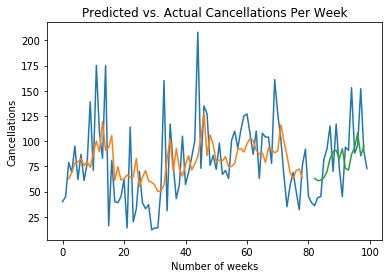

In [28]:
# Plot all predictions
inversetransform, =plt.plot(scaler.inverse_transform(df))
trainpred, =plt.plot(trainpredPlot)
valpred, =plt.plot(valpredPlot)
plt.xlabel('Number of weeks')
plt.ylabel('Cancellations')
plt.title("Predicted vs. Actual Cancellations Per Week")
plt.show()

In [29]:
Y_val=Y_val.reshape(-1)
Y_val.shape
Y_val=pd.Series(Y_val)

In [30]:
predictions=predictions.reshape(-1)
predictions.shape
predictions=pd.Series(predictions)

In [31]:
import numpy as np

def mda(actual: np.ndarray, predicted: np.ndarray):
    """ Mean Directional Accuracy """
    return np.mean((np.sign(actual[1:] - actual[:-1]) == np.sign(predicted[1:] - predicted[:-1])).astype(int))

In [32]:
mda(Y_val, predictions)

0.8823529411764706

In [33]:
X_train

array([[[0.14285714, 0.16836735]],

       [[0.16836735, 0.34183673]],

       [[0.34183673, 0.29081633]],

       [[0.29081633, 0.42346939]],

       [[0.42346939, 0.25510204]],

       [[0.25510204, 0.38265306]],

       [[0.38265306, 0.25      ]],

       [[0.25      , 0.33673469]],

       [[0.33673469, 0.64795918]],

       [[0.64795918, 0.30102041]],

       [[0.30102041, 0.83163265]],

       [[0.83163265, 0.49489796]],

       [[0.49489796, 0.3622449 ]],

       [[0.3622449 , 0.83163265]],

       [[0.83163265, 0.02040816]],

       [[0.02040816, 0.35204082]],

       [[0.35204082, 0.14285714]],

       [[0.14285714, 0.1377551 ]],

       [[0.1377551 , 0.16836735]],

       [[0.16836735, 0.25510204]],

       [[0.25510204, 0.01020408]],

       [[0.01020408, 0.52040816]],

       [[0.52040816, 0.04081633]],

       [[0.04081633, 0.10714286]],

       [[0.10714286, 0.29591837]],

       [[0.29591837, 0.1377551 ]],

       [[0.1377551 , 0.10714286]],

       [[0.10714286, 0.12755

In [34]:
# Test (unseen) predictions
# (t) and (t-2)
Xnew = np.array([[108, 109],[132,181],[118,108],[147,132],[121, 118],[122,147],[137, 121],[144,122],[155, 137],[127,144],[166, 155],[128,127]])
Xnew = scaler.fit_transform(Xnew)
Xnew
Xnewformat = np.reshape(Xnew, (Xnew.shape[0], 1, Xnew.shape[1]))
ynew=model.predict(Xnewformat)

In [35]:
ynew

array([[0.19461131],
       [0.45118645],
       [0.24041042],
       [0.46332243],
       [0.2777534 ],
       [0.34097293],
       [0.37661168],
       [0.42305735],
       [0.5264675 ],
       [0.36337745],
       [0.6325078 ],
       [0.33559632]], dtype=float32)

In [36]:
type(ynew)

numpy.ndarray

In [37]:
ynew.shape

(12, 1)

In [38]:
actual = np.array([[132,118,147,121,122,137,144,155,127,166,128,91]])
actual = (actual - np.min(actual))/np.ptp(actual)
actual

array([[0.54666667, 0.36      , 0.74666667, 0.4       , 0.41333333,
        0.61333333, 0.70666667, 0.85333333, 0.48      , 1.        ,
        0.49333333, 0.        ]])

In [39]:
actual.shape

(1, 12)

In [40]:
actual=actual.reshape(12,-1)
actual.shape

(12, 1)

In [41]:
actual

array([[0.54666667],
       [0.36      ],
       [0.74666667],
       [0.4       ],
       [0.41333333],
       [0.61333333],
       [0.70666667],
       [0.85333333],
       [0.48      ],
       [1.        ],
       [0.49333333],
       [0.        ]])

In [42]:
ynew=ynew.reshape(-1)
actual=actual.reshape(-1)
actualpd=pd.Series(actual)
ynewpd=pd.Series(ynew)

In [43]:
actualpd

0     0.546667
1     0.360000
2     0.746667
3     0.400000
4     0.413333
5     0.613333
6     0.706667
7     0.853333
8     0.480000
9     1.000000
10    0.493333
11    0.000000
dtype: float64

In [44]:
ynewpd

0     0.194611
1     0.451186
2     0.240410
3     0.463322
4     0.277753
5     0.340973
6     0.376612
7     0.423057
8     0.526468
9     0.363377
10    0.632508
11    0.335596
dtype: float32

In [45]:
mda(actualpd, ynewpd)

0.8333333333333334